<a href="https://colab.research.google.com/github/saraswai023-cpu/project/blob/main/stress_depression_ML_NLP_workflow_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Stress & Depression Dataset — Combined ML + NLP Workflow
# Part 1: Traditional ML — Predicting Depression Score

# Uncomment and run if needed:
# !pip install pandas numpy scikit-learn matplotlib seaborn


In [5]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

sns.set(style="whitegrid")


In [6]:
# READING DATA

dt = pd.read_csv('/content/stress_depression_ML_NLP_150000_20columns (1).csv')


In [7]:
dt.shape

(150000, 20)

In [8]:
dt.head(10)

,Patient_ID,Age,Gender,Occupation,Family_Background,Financial_Stress,Sleep_Hours,Exercise_Hours,Social_Support,Stress_Level,Depression_Score,Anxiety_Score,Depression_Severity,Treatment_Recommendation,User_Message,Detected_Emotion,Sentiment,Keywords,Intent,Outcome
0,1,34,Male,Business,Moderate,Medium,7.1,6.3,2,3,7,4,Severe,Counselling,I feel stressed because of exams.,Anxious,Negative,lonely,Seek Help,Needs Follow-up
1,2,55,Male,Engineer,Supportive,Low,3.6,4.3,7,8,15,15,Mild,Lifestyle Change,I feel overwhelmed with work.,Depressed,Positive,lonely,Crisis,Stable
2,3,32,Other,Teacher,Moderate,Medium,8.6,3.3,9,9,16,18,Minimal,CBT,I feel lonely and isolated.,Happy,Negative,sleep,Crisis,Needs Follow-up
3,4,55,Female,Healthcare,Moderate,High,8.2,3.8,7,4,7,8,Severe,CBT,I enjoy spending time with friends.,Depressed,Negative,lonely,Express Emotion,Improved
4,5,24,Male,Healthcare,Moderate,Medium,6.2,0.2,1,8,18,18,Moderate,Lifestyle Change,I feel hopeless and tired.,Neutral,Negative,anxiety,Seek Help,Improved
5,6,32,Female,Healthcare,Moderate,High,5.4,7.3,9,9,21,20,Minimal,Lifestyle Change,My family supports me.,Neutral,Negative,lonely,Ask Advice,Stable
6,7,54,Other,Teacher,Conflict,Medium,6.2,2.9,6,1,2,2,Minimal,Medication,I have lost interest in everything.,Depressed,Positive,lonely,Ask Advice,Needs Follow-up
7,8,29,Male,Healthcare,Moderate,Low,8.1,5.4,2,3,7,8,Minimal,Lifestyle Change,I feel overwhelmed with work.,Sad,Positive,sleep,Seek Help,Needs Follow-up
8,9,22,Male,Teacher,Moderate,High,8.7,5.3,5,3,5,6,Severe,Medication,I have lost interest in everything.,Anxious,Positive,stress,Express Emotion,Stable
9,10,34,Male,Engineer,Conflict,High,8.9,7.7,7,6,12,11,Minimal,CBT,I feel overwhelmed with work.,Anxious,Positive,stress,Ask Advice,Stable


In [9]:
dt.duplicated().sum()

np.int64(0)

In [10]:
# We can see that the dataset contains numeric columns (`Age`, `Sleep_Hours`,

dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Patient_ID                150000 non-null  int64  
 1   Age                       150000 non-null  int64  
 2   Gender                    150000 non-null  object 
 3   Occupation                150000 non-null  object 
 4   Family_Background         150000 non-null  object 
 5   Financial_Stress          150000 non-null  object 
 6   Sleep_Hours               150000 non-null  float64
 7   Exercise_Hours            150000 non-null  float64
 8   Social_Support            150000 non-null  int64  
 9   Stress_Level              150000 non-null  int64  
 10  Depression_Score          150000 non-null  int64  
 11  Anxiety_Score             150000 non-null  int64  
 12  Depression_Severity       150000 non-null  object 
 13  Treatment_Recommendation  150000 non-null  o

In [11]:
dt.columns

Index(['Patient_ID', 'Age', 'Gender', 'Occupation', 'Family_Background',
       'Financial_Stress', 'Sleep_Hours', 'Exercise_Hours', 'Social_Support',
       'Stress_Level', 'Depression_Score', 'Anxiety_Score',
       'Depression_Severity', 'Treatment_Recommendation', 'User_Message',
       'Detected_Emotion', 'Sentiment', 'Keywords', 'Intent', 'Outcome'],
      dtype='object')

In [12]:
print("Number of Rows are:", dt.shape[0])
print("Number of columns are:", dt.shape[1])


Number of Rows are: 150000
Number of columns are: 20


In [13]:
dt.isna().sum()

,0
Patient_ID,0
Age,0
Gender,0
Occupation,0
Family_Background,0
Financial_Stress,0
Sleep_Hours,0
Exercise_Hours,0
Social_Support,0
Stress_Level,0


In [14]:
dt.describe()

,Patient_ID,Age,Sleep_Hours,Exercise_Hours,Social_Support,Stress_Level,Depression_Score,Anxiety_Score
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,75000.500000,43.977180,6.251752,3.995619,5.508200,5.505713,11.029313,10.986180
std,43301.414527,15.290515,1.588028,2.311595,2.868514,2.872081,6.060212,5.877585
min,1.000000,18.000000,3.500000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,37500.750000,31.000000,4.900000,2.000000,3.000000,3.000000,6.000000,6.000000
50%,75000.500000,44.000000,6.300000,4.000000,6.000000,6.000000,11.000000,11.000000
75%,112500.250000,57.000000,7.600000,6.000000,8.000000,8.000000,16.000000,16.000000
max,150000.000000,70.000000,9.000000,8.000000,10.000000,10.000000,23.000000,21.000000


In [15]:
dt.duplicated().sum()

np.int64(0)

In [16]:
dt.drop_duplicates(inplace=True)
dt.dropna(how="any", inplace=True)


In [17]:
dt.isna().sum()

,0
Patient_ID,0
Age,0
Gender,0
Occupation,0
Family_Background,0
Financial_Stress,0
Sleep_Hours,0
Exercise_Hours,0
Social_Support,0
Stress_Level,0


In [18]:
print("Number of Rows are:", dt.shape[0])
print("Number of columns are:", dt.shape[1])


Number of Rows are: 150000
Number of columns are: 20


In [19]:
dt.describe()

,Patient_ID,Age,Sleep_Hours,Exercise_Hours,Social_Support,Stress_Level,Depression_Score,Anxiety_Score
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,75000.500000,43.977180,6.251752,3.995619,5.508200,5.505713,11.029313,10.986180
std,43301.414527,15.290515,1.588028,2.311595,2.868514,2.872081,6.060212,5.877585
min,1.000000,18.000000,3.500000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,37500.750000,31.000000,4.900000,2.000000,3.000000,3.000000,6.000000,6.000000
50%,75000.500000,44.000000,6.300000,4.000000,6.000000,6.000000,11.000000,11.000000
75%,112500.250000,57.000000,7.600000,6.000000,8.000000,8.000000,16.000000,16.000000
max,150000.000000,70.000000,9.000000,8.000000,10.000000,10.000000,23.000000,21.000000


In [20]:
dt["Depression_Score"].describe()

,Depression_Score
count,150000.000000
mean,11.029313
std,6.060212
min,0.000000
25%,6.000000
50%,11.000000
75%,16.000000
max,23.000000


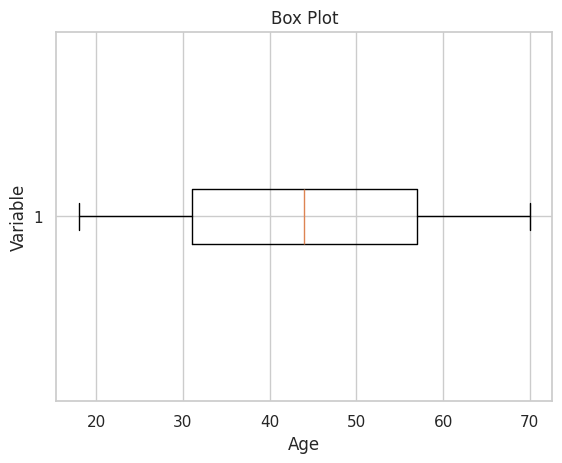

In [21]:
# Outlier Detection

plt.boxplot(dt['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()


In [22]:
# Categorical columns
cat_col = [col for col in dt.columns if dt[col].dtype == 'object' or str(dt[col].dtype).lower().startswith('str')]
print('Categorical columns :', cat_col)
# Numerical columns
num_col = [col for col in dt.columns if col not in cat_col]
print('Numerical columns :', num_col)


Categorical columns : ['Gender', 'Occupation', 'Family_Background', 'Financial_Stress', 'Depression_Severity', 'Treatment_Recommendation', 'User_Message', 'Detected_Emotion', 'Sentiment', 'Keywords', 'Intent', 'Outcome']
Numerical columns : ['Patient_ID', 'Age', 'Sleep_Hours', 'Exercise_Hours', 'Social_Support', 'Stress_Level', 'Depression_Score', 'Anxiety_Score']


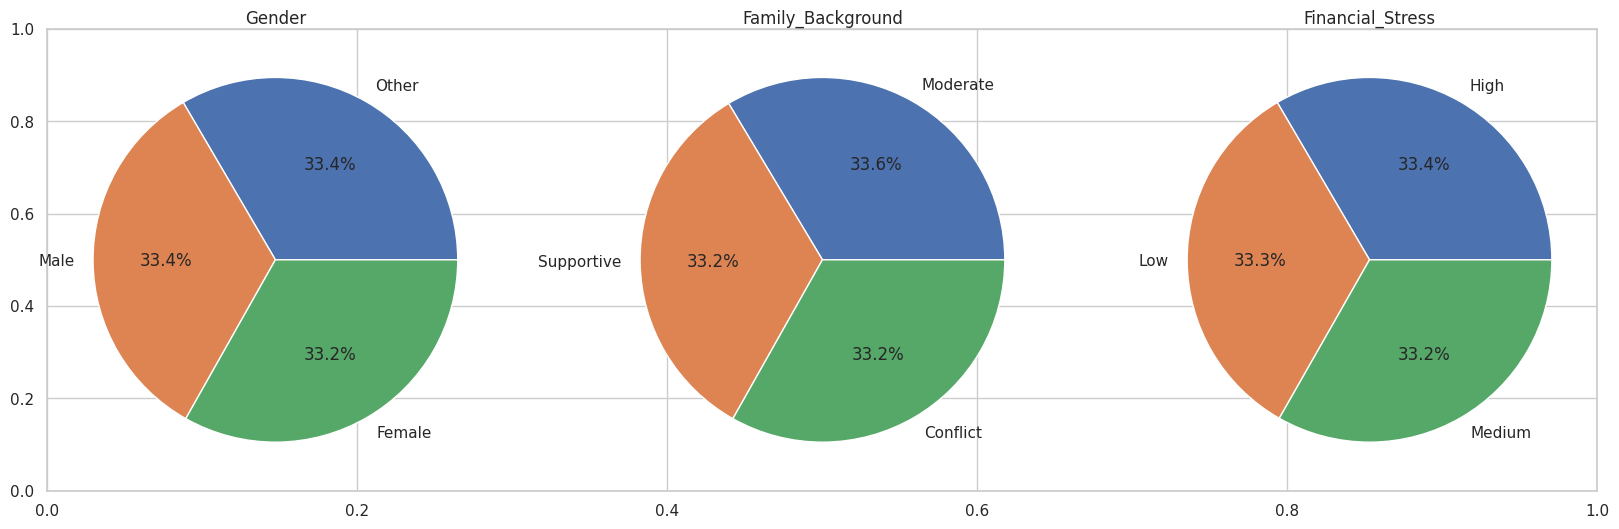

In [23]:
# The data is spread fairly evenly across `Gender`, `Occupation`,

features = ['Gender', 'Family_Background', 'Financial_Stress']

plt.subplots(figsize=(20, 6))
for i, col in enumerate(features):
    plt.subplot(1, 3, i + 1)
    x = dt[col].value_counts()
    plt.pie(x.values, labels=x.index, autopct='%1.1f%%')
    plt.title(col)
plt.show()


In [24]:
dt['Gender'].unique()

array(['Male', 'Other', 'Female'], dtype=object)

In [25]:
dt['Occupation'].unique()

array(['Business', 'Engineer', 'Teacher', 'Healthcare', 'Unemployed',
       'Student'], dtype=object)

In [26]:
dt['Family_Background'].unique()

array(['Moderate', 'Supportive', 'Conflict'], dtype=object)

In [27]:
dt['Financial_Stress'].unique()

array(['Medium', 'Low', 'High'], dtype=object)

In [28]:
#Checking the percentage of missing data
round((dt.isnull().sum() / dt.shape[0]) * 100, 2)


,0
Patient_ID,0.0
Age,0.0
Gender,0.0
Occupation,0.0
Family_Background,0.0
Financial_Stress,0.0
Sleep_Hours,0.0
Exercise_Hours,0.0
Social_Support,0.0
Stress_Level,0.0


In [29]:
dt.head()

,Patient_ID,Age,Gender,Occupation,Family_Background,Financial_Stress,Sleep_Hours,Exercise_Hours,Social_Support,Stress_Level,Depression_Score,Anxiety_Score,Depression_Severity,Treatment_Recommendation,User_Message,Detected_Emotion,Sentiment,Keywords,Intent,Outcome
0,1,34,Male,Business,Moderate,Medium,7.1,6.3,2,3,7,4,Severe,Counselling,I feel stressed because of exams.,Anxious,Negative,lonely,Seek Help,Needs Follow-up
1,2,55,Male,Engineer,Supportive,Low,3.6,4.3,7,8,15,15,Mild,Lifestyle Change,I feel overwhelmed with work.,Depressed,Positive,lonely,Crisis,Stable
2,3,32,Other,Teacher,Moderate,Medium,8.6,3.3,9,9,16,18,Minimal,CBT,I feel lonely and isolated.,Happy,Negative,sleep,Crisis,Needs Follow-up
3,4,55,Female,Healthcare,Moderate,High,8.2,3.8,7,4,7,8,Severe,CBT,I enjoy spending time with friends.,Depressed,Negative,lonely,Express Emotion,Improved
4,5,24,Male,Healthcare,Moderate,Medium,6.2,0.2,1,8,18,18,Moderate,Lifestyle Change,I feel hopeless and tired.,Neutral,Negative,anxiety,Seek Help,Improved


In [30]:
# calculate summary statistics
mean = dt['Age'].mean()
std = dt['Age'].std()
# Calculate the lower and upper bounds
lower_bound = mean - std * 2
upper_bound = mean + std * 2

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

# Drop the outliers on Age
dt1 = dt[(dt['Age'] >= lower_bound) & (dt['Age'] <= upper_bound)]
print(dt1.shape)


Lower Bound : 13.396150286799692
Upper Bound : 74.5582097132003
(150000, 20)


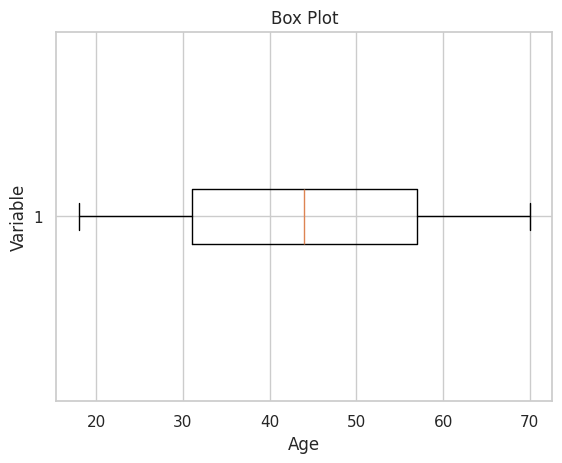

In [31]:
#Checking again outliers on Age
plt.boxplot(dt1['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()


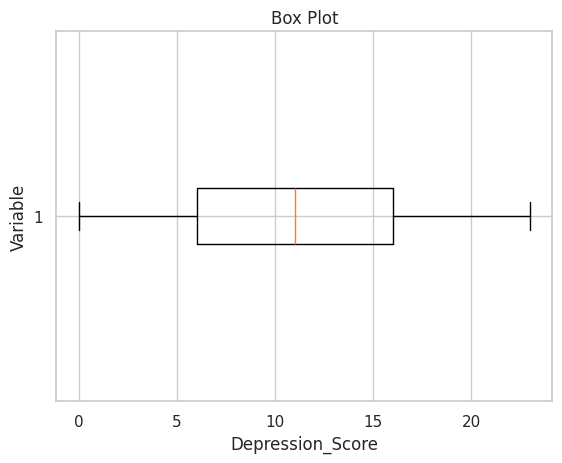

In [32]:
#check outliers Depression_Score
plt.boxplot(dt1['Depression_Score'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Depression_Score')
plt.title('Box Plot')
plt.show()


In [33]:
# calculate summary statistics
mean = dt1['Depression_Score'].mean()
std = dt1['Depression_Score'].std()
lower_bound = mean - std * 2
upper_bound = mean + std * 2

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

# Drop the outliers on Depression_Score
dt2 = dt1[(dt1['Depression_Score'] >= lower_bound) & (dt1['Depression_Score'] <= upper_bound)]
print(dt2.shape)


Lower Bound : -1.0911100206073936
Upper Bound : 23.149736687274057
(150000, 20)


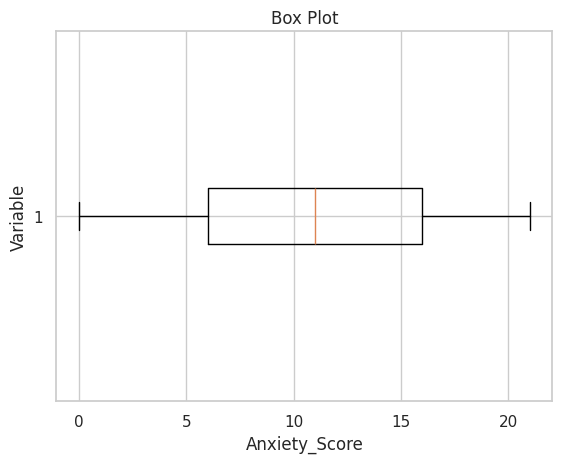

In [34]:
#check outliers Anxiety_Score
plt.boxplot(dt2['Anxiety_Score'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Anxiety_Score')
plt.title('Box Plot')
plt.show()


In [35]:
# calculate summary statistics
mean = dt2['Anxiety_Score'].mean()
std = dt2['Anxiety_Score'].std()
lower_bound = mean - std * 2
upper_bound = mean + std * 2

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

# Drop the outliers on Anxiety_Score
dt3 = dt2[(dt2['Anxiety_Score'] >= lower_bound) & (dt2['Anxiety_Score'] <= upper_bound)].copy()
print(dt3.shape)


Lower Bound : -0.7689900933628078
Upper Bound : 22.741350093362804
(150000, 20)


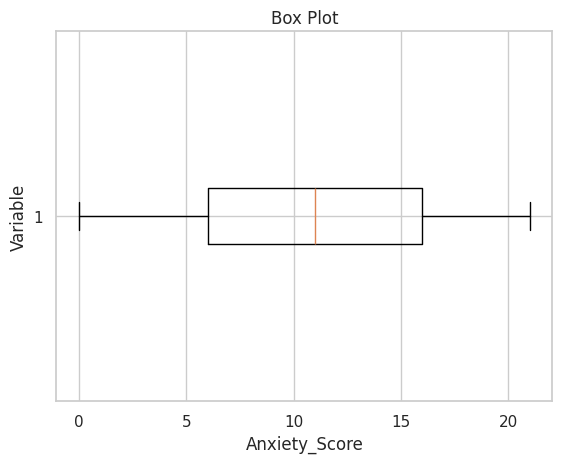

In [36]:
#check outliers AGAIN
plt.boxplot(dt3['Anxiety_Score'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Anxiety_Score')
plt.title('Box Plot')
plt.show()


In [37]:
# Encoding categorical variables

label = LabelEncoder()

# Gender
label.fit(dt3.Gender.drop_duplicates())
dt3['Gender'] = label.transform(dt3['Gender'])

# Occupation
label.fit(dt3.Occupation.drop_duplicates())
dt3['Occupation'] = label.transform(dt3['Occupation'])

# Family_Background
label.fit(dt3.Family_Background.drop_duplicates())
dt3['Family_Background'] = label.transform(dt3['Family_Background'])

# Financial_Stress
label.fit(dt3.Financial_Stress.drop_duplicates())
dt3['Financial_Stress'] = label.transform(dt3['Financial_Stress'])

dt3.head()


,Patient_ID,Age,Gender,Occupation,Family_Background,Financial_Stress,Sleep_Hours,Exercise_Hours,Social_Support,Stress_Level,Depression_Score,Anxiety_Score,Depression_Severity,Treatment_Recommendation,User_Message,Detected_Emotion,Sentiment,Keywords,Intent,Outcome
0,1,34,1,0,1,2,7.1,6.3,2,3,7,4,Severe,Counselling,I feel stressed because of exams.,Anxious,Negative,lonely,Seek Help,Needs Follow-up
1,2,55,1,1,2,1,3.6,4.3,7,8,15,15,Mild,Lifestyle Change,I feel overwhelmed with work.,Depressed,Positive,lonely,Crisis,Stable
2,3,32,2,4,1,2,8.6,3.3,9,9,16,18,Minimal,CBT,I feel lonely and isolated.,Happy,Negative,sleep,Crisis,Needs Follow-up
3,4,55,0,2,1,0,8.2,3.8,7,4,7,8,Severe,CBT,I enjoy spending time with friends.,Depressed,Negative,lonely,Express Emotion,Improved
4,5,24,1,2,1,2,6.2,0.2,1,8,18,18,Moderate,Lifestyle Change,I feel hopeless and tired.,Neutral,Negative,anxiety,Seek Help,Improved


In [38]:
# OR YOU CAN USE THIS BELOW METHOD

#dt3['Gender']=dt3['Gender'].map({'Male':0,'Female':1,'Other':2})
#dt3['Financial_Stress']=dt3['Financial_Stress'].map({'Low':0,'Medium':1,'High':2})


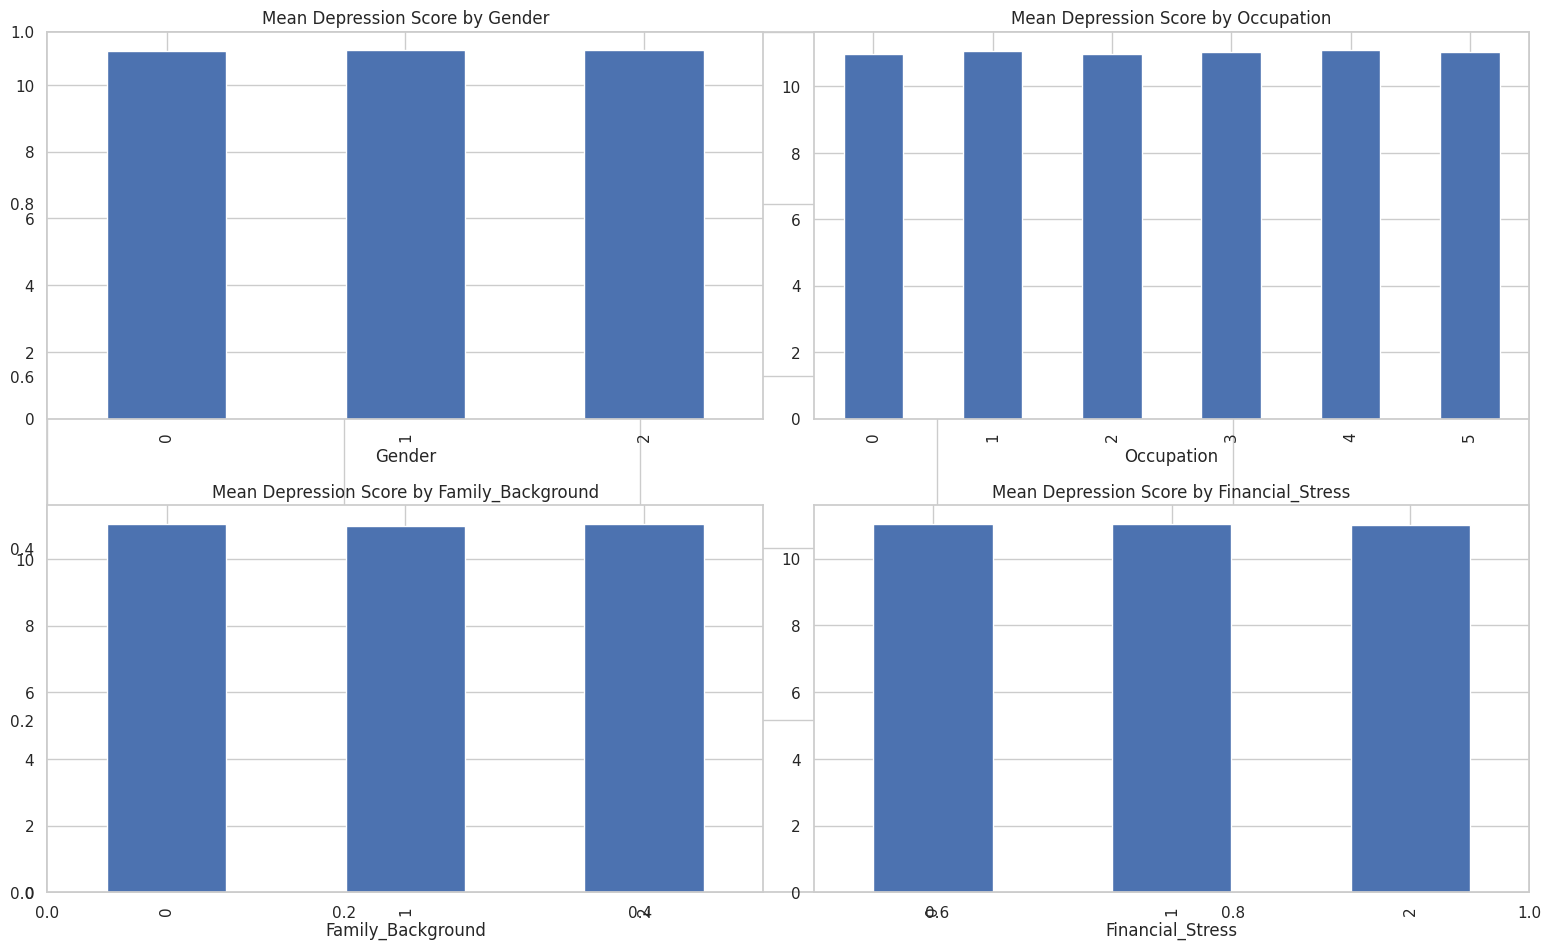

In [39]:
# Now let's look at some of the observations shown in the graphs below:

features = ['Gender', 'Occupation', 'Family_Background', 'Financial_Stress']

plt.subplots(figsize=(16, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    dt3.groupby(col)['Depression_Score'].mean().plot.bar()
    plt.title(f'Mean Depression Score by {col}')
plt.tight_layout()
plt.show()


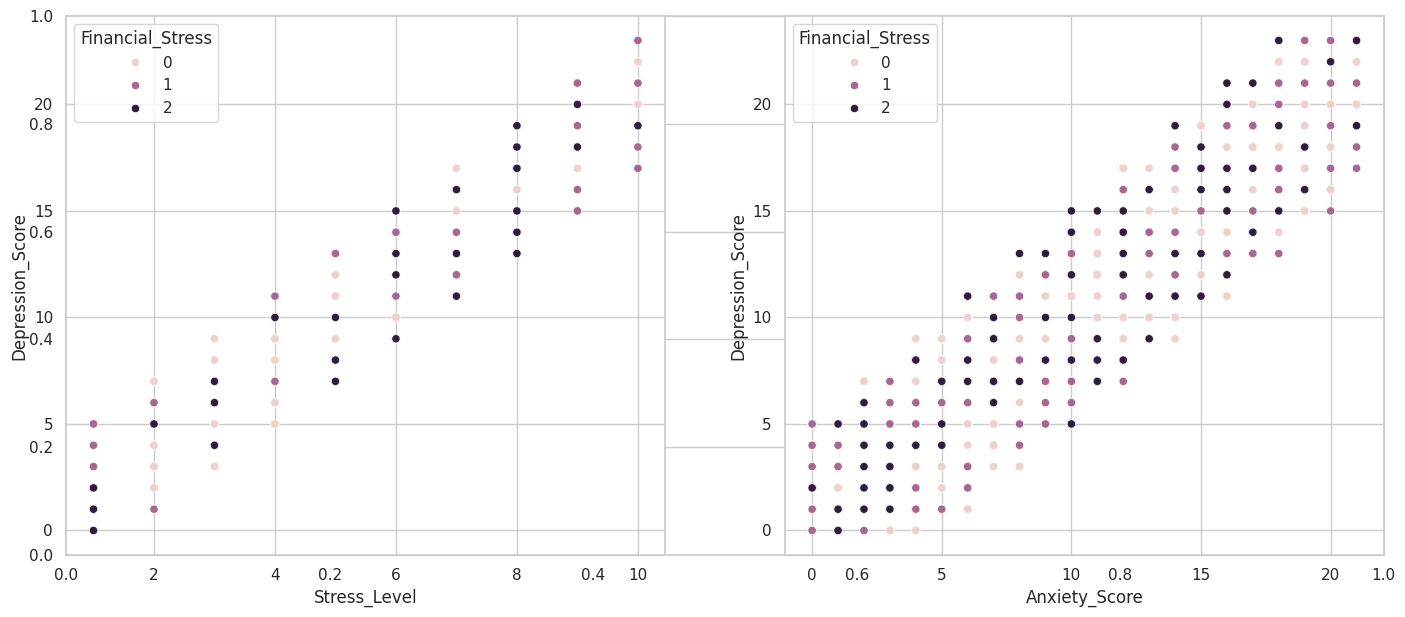

In [40]:
# A clear distinction can be observed for `Stress_Level` and `Anxiety_Score`:

features = ['Stress_Level', 'Anxiety_Score']

plt.subplots(figsize=(17, 7))
for i, col in enumerate(features):
    plt.subplot(1, 2, i + 1)
    sns.scatterplot(data=dt3, x=col, y='Depression_Score', hue='Financial_Stress')
plt.show()


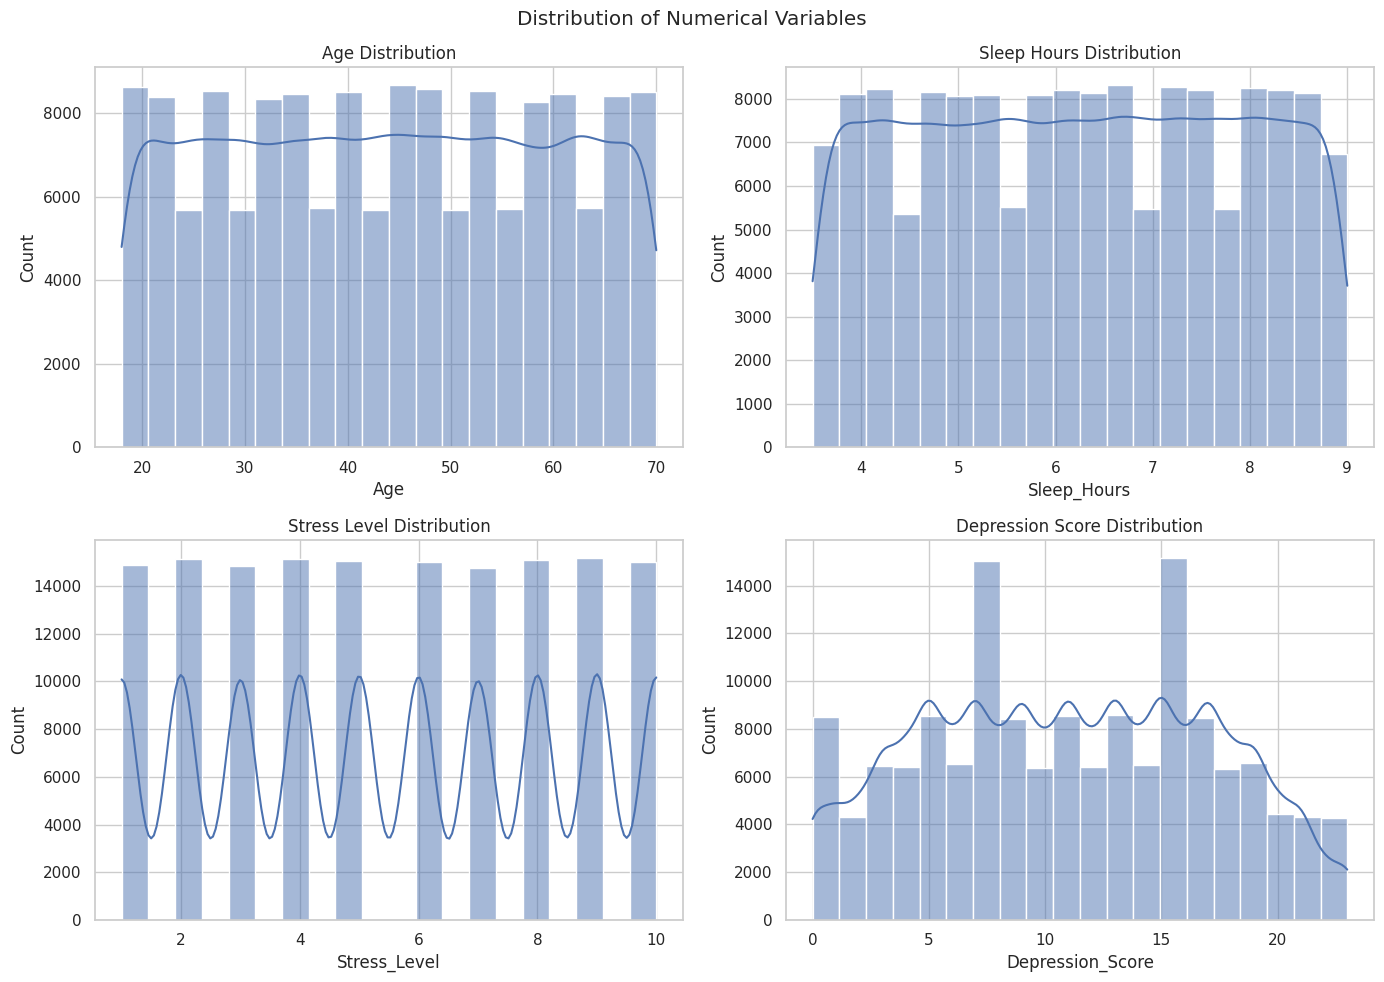

In [41]:
# More Univariate analysis

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Numerical Variables')

sns.histplot(dt3['Age'], kde=True, bins=20, ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution')

sns.histplot(dt3['Sleep_Hours'], kde=True, bins=20, ax=axes[0, 1])
axes[0, 1].set_title('Sleep Hours Distribution')

sns.histplot(dt3['Stress_Level'], kde=True, bins=20, ax=axes[1, 0])
axes[1, 0].set_title('Stress Level Distribution')

sns.histplot(dt3['Depression_Score'], kde=True, bins=20, ax=axes[1, 1])
axes[1, 1].set_title('Depression Score Distribution')

plt.tight_layout()
plt.show()


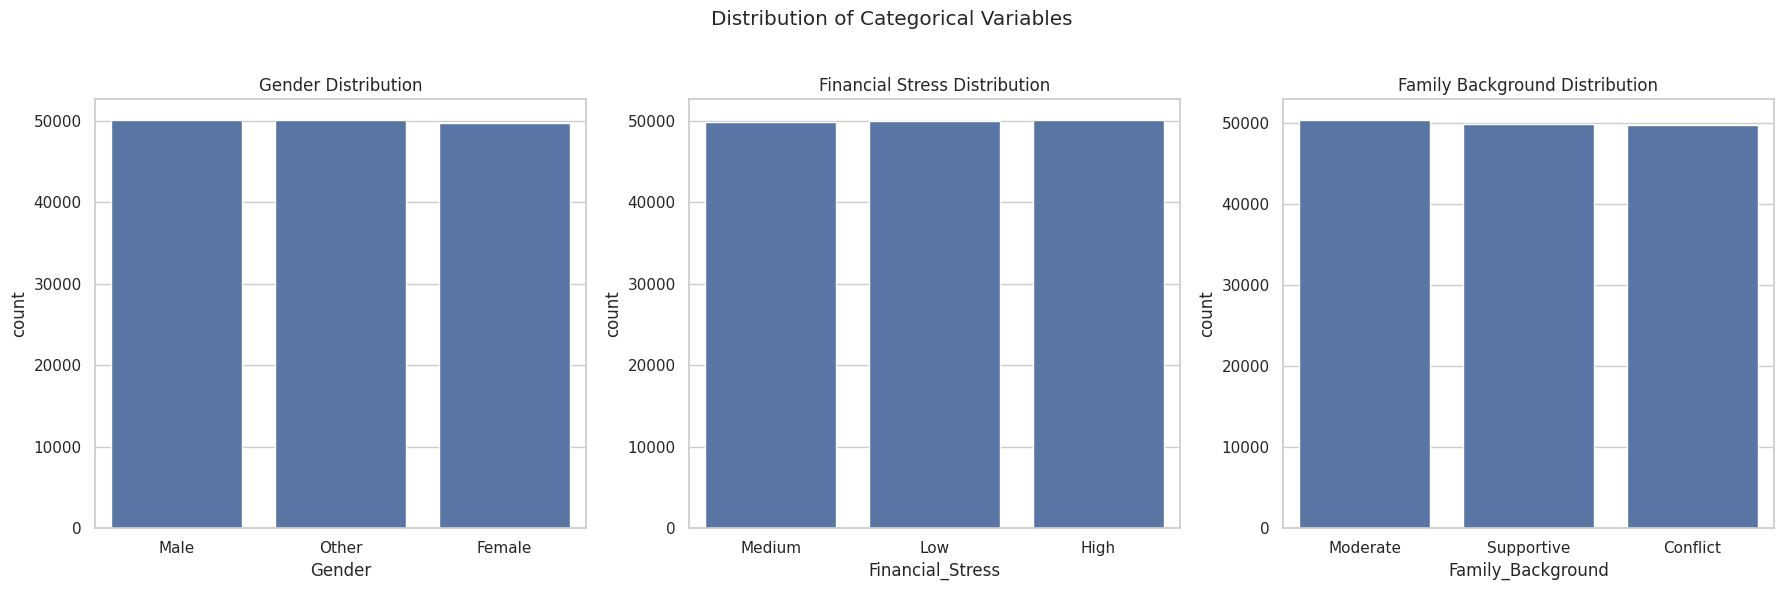

In [42]:
# Here's what we can observe from the histograms:
# Next, let's look at the categorical variables (`Gender`, `Financial_Stress`, `Family_Background`) using bar plots.

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribution of Categorical Variables')

sns.countplot(x='Gender', data=dt, ax=axes[0])
axes[0].set_title('Gender Distribution')

sns.countplot(x='Financial_Stress', data=dt, ax=axes[1])
axes[1].set_title('Financial Stress Distribution')

sns.countplot(x='Family_Background', data=dt, ax=axes[2])
axes[2].set_title('Family Background Distribution')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


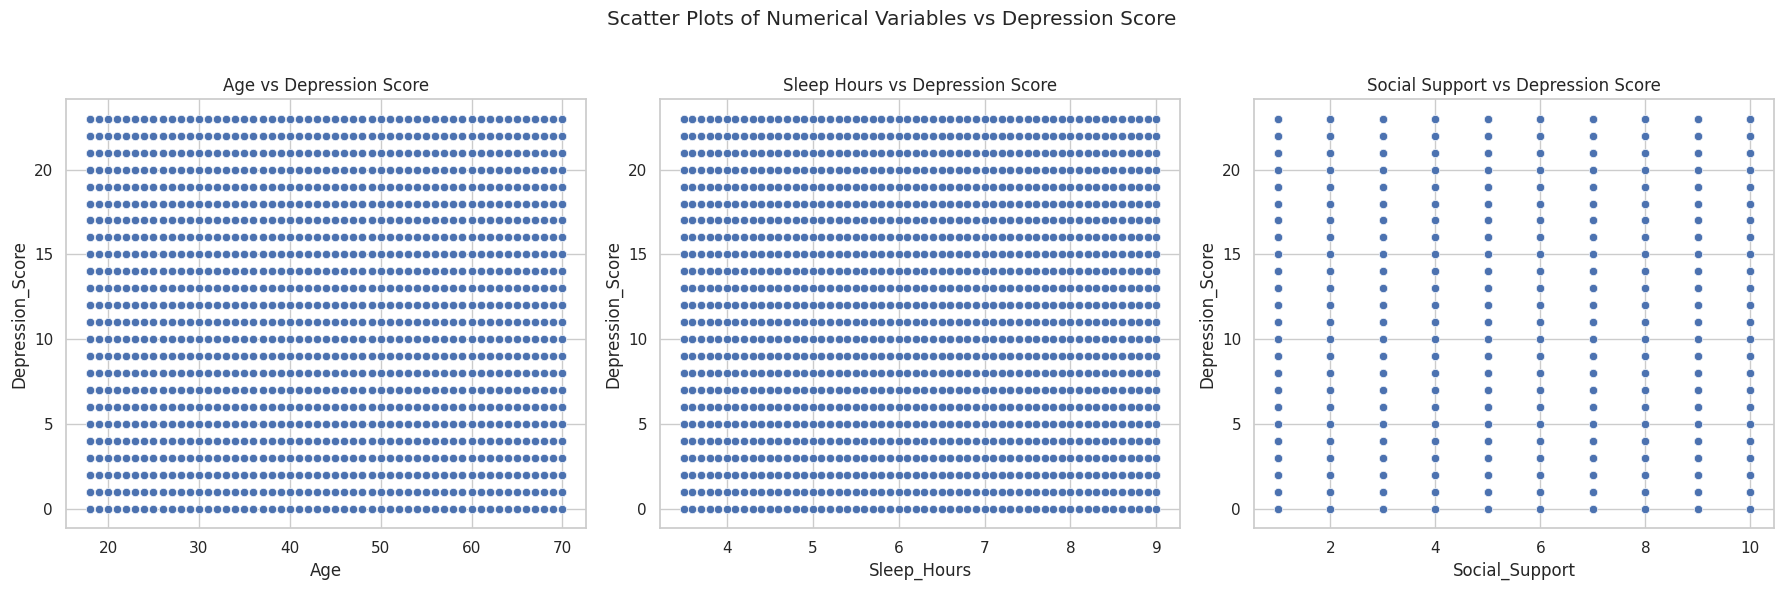

In [43]:
# Bivariate Analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Scatter Plots of Numerical Variables vs Depression Score')

sns.scatterplot(x='Age', y='Depression_Score', data=dt3, ax=axes[0])
axes[0].set_title('Age vs Depression Score')

sns.scatterplot(x='Sleep_Hours', y='Depression_Score', data=dt3, ax=axes[1])
axes[1].set_title('Sleep Hours vs Depression Score')

sns.scatterplot(x='Social_Support', y='Depression_Score', data=dt3, ax=axes[2])
axes[2].set_title('Social Support vs Depression Score')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


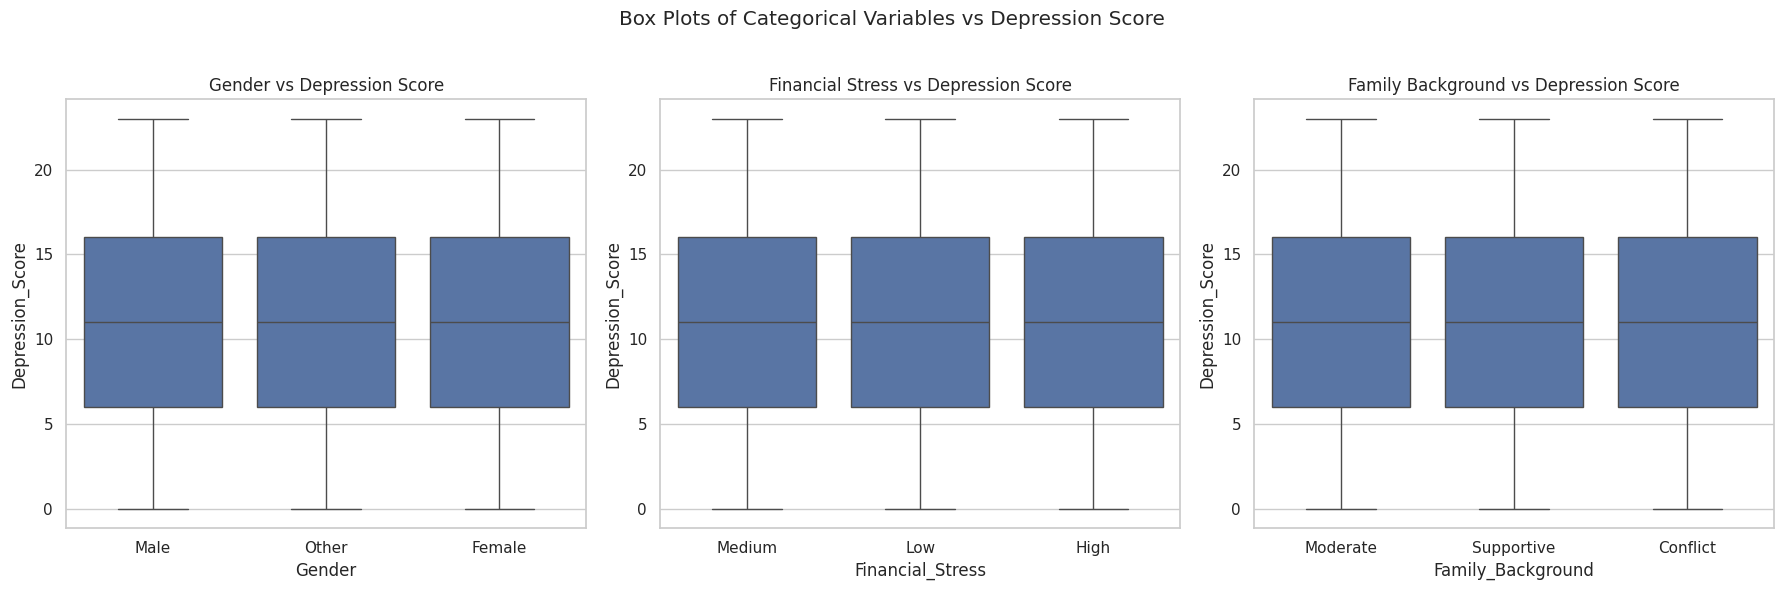

In [44]:
# Observations from the scatter plots:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Box Plots of Categorical Variables vs Depression Score')

sns.boxplot(x='Gender', y='Depression_Score', data=dt, ax=axes[0])
axes[0].set_title('Gender vs Depression Score')

sns.boxplot(x='Financial_Stress', y='Depression_Score', data=dt, ax=axes[1])
axes[1].set_title('Financial Stress vs Depression Score')

sns.boxplot(x='Family_Background', y='Depression_Score', data=dt, ax=axes[2])
axes[2].set_title('Family Background vs Depression Score')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


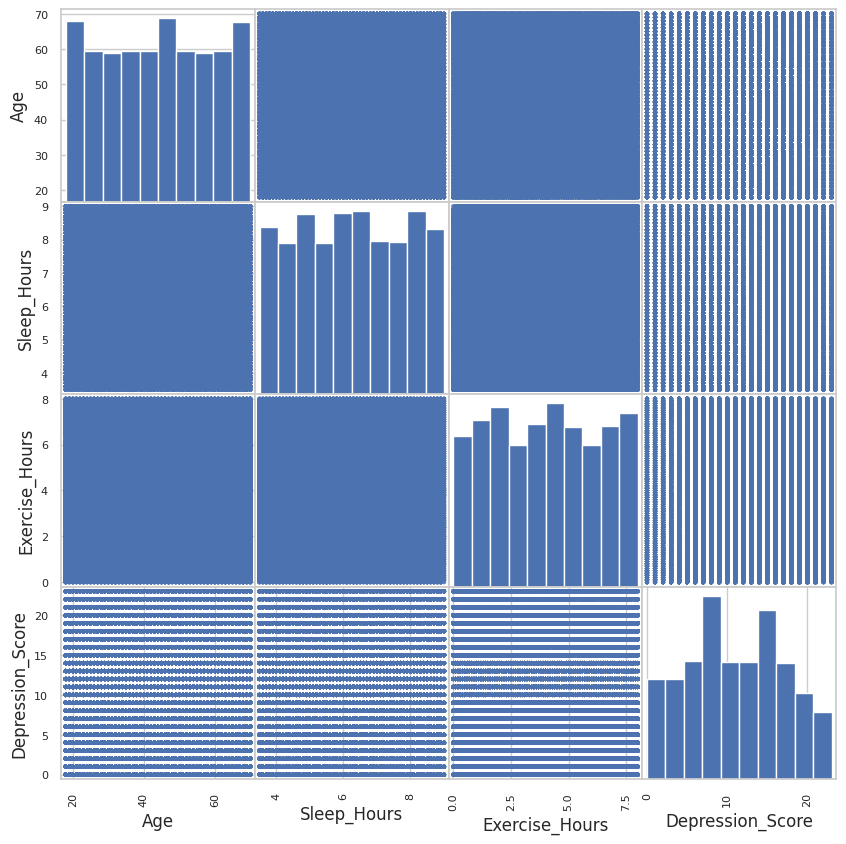

In [45]:
scatter_matrix(dt3[['Age', 'Sleep_Hours', 'Exercise_Hours', 'Depression_Score']], figsize=(10, 10))
plt.show()


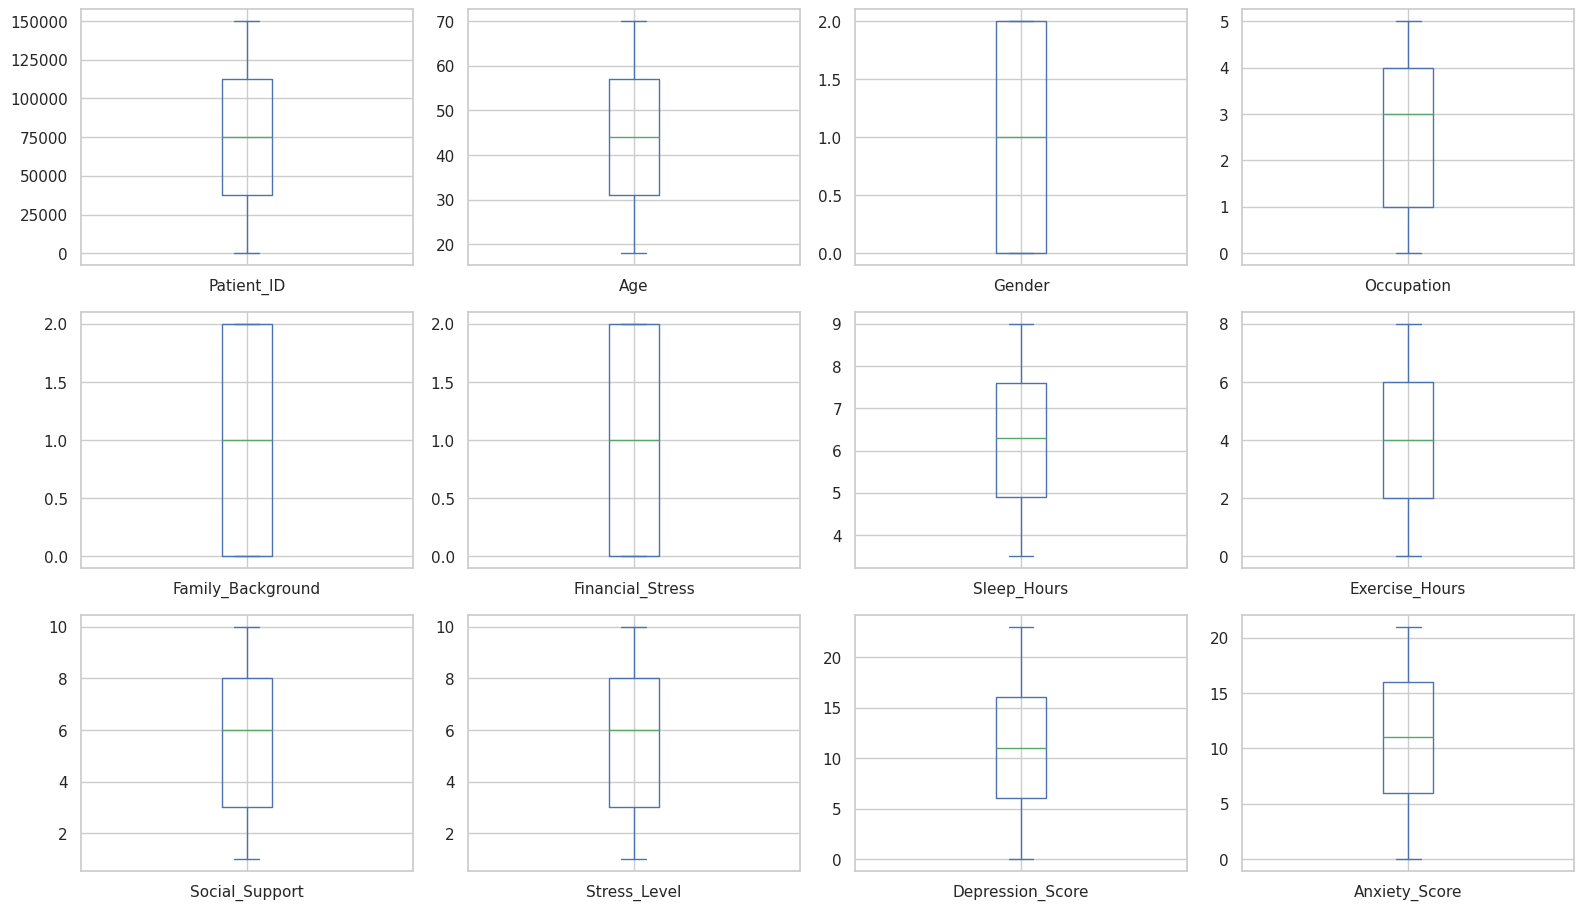

In [46]:
dt3.plot(kind='box', subplots=True, layout=(4, 4), figsize=(16, 12), sharex=False, sharey=False)
plt.tight_layout()
plt.show()


In [47]:
# The EDA has provided valuable insights into how various features relate to
# Feature Engineering for Building Regression Models
# Data Preparation for Building Regression Models

# Define the features and the target
X_full = dt3.drop(columns=['Patient_ID', 'Depression_Score', 'Depression_Severity',
                            'Treatment_Recommendation', 'User_Message', 'Detected_Emotion',
                            'Sentiment', 'Keywords', 'Intent', 'Outcome'])
y_full = dt3['Depression_Score']

# Identify numerical and categorical columns
numerical_cols = ['Age', 'Sleep_Hours', 'Exercise_Hours', 'Social_Support', 'Stress_Level', 'Anxiety_Score']
categorical_cols = ['Gender', 'Occupation', 'Family_Background', 'Financial_Stress']

# Preprocessing for numerical data: standardization
numerical_transformer = StandardScaler()

# Preprocessing for categorical data: one-hot encoding
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols),
])

print("Preprocessor ready:", preprocessor)


Preprocessor ready: ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Age', 'Sleep_Hours', 'Exercise_Hours',
                                  'Social_Support', 'Stress_Level',
                                  'Anxiety_Score']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Gender', 'Occupation', 'Family_Background',
                                  'Financial_Stress'])])


In [48]:
# Now the discrete data is encoded and the preprocessing/wrangling step is complete. Next we move to model development.

dt3[numerical_cols + categorical_cols + ['Depression_Score']].corr()

,Age,Sleep_Hours,Exercise_Hours,Social_Support,Stress_Level,Anxiety_Score,Gender,Occupation,Family_Background,Financial_Stress,Depression_Score
Age,1.000000,-0.002959,-0.000593,0.000389,0.000716,0.000501,0.004222,0.000651,0.002471,0.002265,-0.000373
Sleep_Hours,-0.002959,1.000000,-0.001272,0.000706,-0.001134,-0.001228,0.001232,0.000743,-0.005447,0.001599,-0.001537
Exercise_Hours,-0.000593,-0.001272,1.000000,0.001773,-0.002892,-0.002940,-0.001179,0.001642,0.001074,0.004271,-0.003801
Social_Support,0.000389,0.000706,0.001773,1.000000,-0.000967,-0.001096,-0.001822,0.001736,0.000169,-0.000053,-0.002243
Stress_Level,0.000716,-0.001134,-0.002892,-0.000967,1.000000,0.971581,0.003050,0.002934,0.002460,-0.000444,0.945281
Anxiety_Score,0.000501,-0.001228,-0.002940,-0.001096,0.971581,1.000000,0.003018,0.003124,0.001878,-0.000937,0.918325
Gender,0.004222,0.001232,-0.001179,-0.001822,0.003050,0.003018,1.000000,0.003126,-0.002970,-0.002263,0.002567
Occupation,0.000651,0.000743,0.001642,0.001736,0.002934,0.003124,0.003126,1.000000,-0.009447,-0.002871,0.003320
Family_Background,0.002471,-0.005447,0.001074,0.000169,0.002460,0.001878,-0.002970,-0.009447,1.000000,-0.003996,0.001413
Financial_Stress,0.002265,0.001599,0.004271,-0.000053,-0.000444,-0.000937,-0.002263,-0.002871,-0.003996,1.000000,-0.000849


In [49]:
# Model Development

X = dt3[numerical_cols + categorical_cols]
Y = dt3[['Depression_Score']]

# Sample down for speed while iterating over random_state values
sample_idx = X.sample(n=min(15000, len(X)), random_state=1).index
X_search = X.loc[sample_idx]
Y_search = Y.loc[sample_idx]

l1 = []
for i in range(40, 45):
    xtrain, xtest, ytrain, ytest = train_test_split(X_search, Y_search, test_size=0.2, random_state=i)
    lrmodel = LinearRegression()
    lrmodel.fit(xtrain, ytrain)
    l1.append(lrmodel.score(xtrain, ytrain))

pd.DataFrame({'random_state': range(40, 45), 'train_R2': l1})


,random_state,train_R2
0,40,0.894055
1,41,0.893764
2,42,0.893772
3,43,0.893856
4,44,0.892944


In [50]:
X.head()

,Age,Sleep_Hours,Exercise_Hours,Social_Support,Stress_Level,Anxiety_Score,Gender,Occupation,Family_Background,Financial_Stress
0,34,7.1,6.3,2,3,4,1,0,1,2
1,55,3.6,4.3,7,8,15,1,1,2,1
2,32,8.6,3.3,9,9,18,2,4,1,2
3,55,8.2,3.8,7,4,8,0,2,1,0
4,24,6.2,0.2,1,8,18,1,2,1,2


In [51]:
# After trying a few random_state values, we fix `random_state=42` for

sample_idx = X.sample(n=min(15000, len(X)), random_state=42).index
X_s = X.loc[sample_idx]
Y_s = Y.loc[sample_idx]

xtrain, xtest, ytrain, ytest = train_test_split(X_s, Y_s, test_size=0.2, random_state=42)

lrmodel = LinearRegression()
lrmodel.fit(xtrain, ytrain)
print(lrmodel.score(xtrain, ytrain))
print(lrmodel.score(xtest, ytest))
print(cross_val_score(lrmodel, X_s, Y_s, cv=5).mean())


0.8937161015399177
0.8922223822446947
0.8932305978509353


In [52]:
svrmodel = SVR()
svrmodel.fit(xtrain, ytrain.values.ravel())
ypredtrain1 = svrmodel.predict(xtrain)
ypredtest1 = svrmodel.predict(xtest)
print(r2_score(ytrain, ypredtrain1))
print(r2_score(ytest, ypredtest1))
print(cross_val_score(svrmodel, X_s, Y_s.values.ravel(), cv=5).mean())


0.8852302393173674
0.8827712603492424
0.8842538547494458


In [53]:
rfmodel = RandomForestRegressor(random_state=42)
rfmodel.fit(xtrain, ytrain.values.ravel())
ypredtrain2 = rfmodel.predict(xtrain)
ypredtest2 = rfmodel.predict(xtest)
print(r2_score(ytrain, ypredtrain2))
print(r2_score(ytest, ypredtest2))

estimator = RandomForestRegressor(random_state=42)
param_grid = {'n_estimators': [40, 100, 150]}
grid = GridSearchCV(estimator, param_grid, scoring="r2", cv=3)
grid.fit(xtrain, ytrain.values.ravel())
print(grid.best_params_)

rfmodel = grid.best_estimator_
ypredtest2 = rfmodel.predict(xtest)
print("Tuned RF test R2:", r2_score(ytest, ypredtest2))


0.9842913335795302
0.8850583613697175
{'n_estimators': 150}
Tuned RF test R2: 0.8855782176148502


In [54]:
gbmodel = GradientBoostingRegressor(random_state=42)
gbmodel.fit(xtrain, ytrain.values.ravel())
ypredtrain3 = gbmodel.predict(xtrain)
ypredtest3 = gbmodel.predict(xtest)
print(r2_score(ytrain, ypredtrain3))
print(r2_score(ytest, ypredtest3))

estimator = GradientBoostingRegressor(random_state=42)
param_grid = {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1, 0.2]}
grid_gb = GridSearchCV(estimator, param_grid, scoring="r2", cv=3)
grid_gb.fit(xtrain, ytrain.values.ravel())
print(grid_gb.best_params_)

gbmodel = grid_gb.best_estimator_
ypredtest3 = gbmodel.predict(xtest)
print("Tuned GB test R2:", r2_score(ytest, ypredtest3))


0.8967168899978952
0.891656977213376
{'learning_rate': 0.05, 'n_estimators': 100}
Tuned GB test R2: 0.8919806392890867


In [55]:
final_data = pd.DataFrame({
    'Models': ['LR', 'SVR', 'RFR', 'GBR'],
    'Test_R2': [
        r2_score(ytest, lrmodel.predict(xtest)),
        r2_score(ytest, ypredtest1),
        r2_score(ytest, ypredtest2),
        r2_score(ytest, ypredtest3),
    ],
})
final_data


,Models,Test_R2
0,LR,0.892222
1,SVR,0.882771
2,RFR,0.885578
3,GBR,0.891981


In [56]:
# Now let's identify the important features for predicting depression score.

feats = pd.DataFrame(data=gbmodel.feature_importances_, index=X.columns, columns=['Importance'])
feats.sort_values('Importance', ascending=False)


,Importance
Stress_Level,0.997836
Anxiety_Score,0.001281
Exercise_Hours,0.000336
Sleep_Hours,0.000131
Age,0.000129
Family_Background,0.000109
Social_Support,0.000088
Financial_Stress,0.000064
Gender,0.000016
Occupation,0.000012


In [57]:
important_features = feats[feats['Importance'] > 0.01]
important_features


,Importance
Stress_Level,0.997836


In [58]:
pred = lrmodel.predict(xtest)
print("R2 score:", r2_score(ytest, pred))


R2 score: 0.8922223822446947


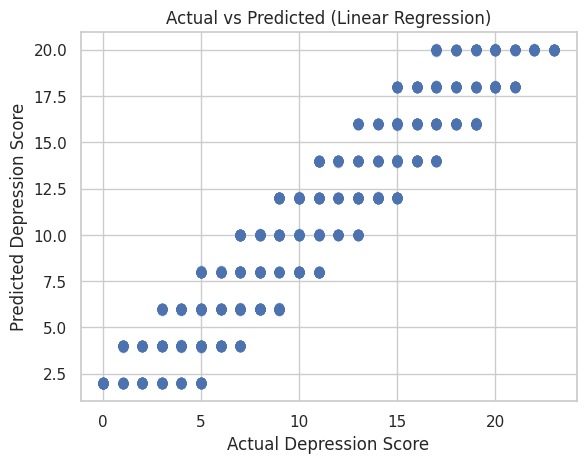

In [59]:
plt.scatter(ytest, pred, alpha=0.4)
plt.xlabel('Actual Depression Score')
plt.ylabel('Predicted Depression Score')
plt.title('Actual vs Predicted (Linear Regression)')
plt.show()


In [60]:
# Prediction on New Data

new_patient = {
    'Age': 29,
    'Sleep_Hours': 4.5,
    'Exercise_Hours': 0.5,
    'Social_Support': 2,
    'Stress_Level': 9,
    'Anxiety_Score': 18,
    'Gender': 0,
    'Occupation': 5,
    'Family_Background': 2,
    'Financial_Stress': 2,
}
cust_df = pd.DataFrame(new_patient, index=[0])[X.columns]
cust_df


,Age,Sleep_Hours,Exercise_Hours,Social_Support,Stress_Level,Anxiety_Score,Gender,Occupation,Family_Background,Financial_Stress
0,29,4.5,0.5,2,9,18,0,5,2,2


In [61]:
score_pred = gbmodel.predict(cust_df)
print("Predicted depression score for the new patient:", score_pred[0].round(2))


Predicted depression score for the new patient: 17.89


In [62]:
# Part 2: NLP Workflow — Sentiment Analysis on Patient Messages

# Uncomment and run if needed:
# !pip install nltk wordcloud gensim datasets transformers accelerate torch


In [63]:
import os
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"

import warnings
warnings.filterwarnings("ignore")

import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Optional heavier NLP dependencies - fall back gracefully if not installed
try:
    import nltk
    from nltk.tokenize import sent_tokenize, word_tokenize
    from nltk.corpus import stopwords
    from nltk.stem import PorterStemmer, WordNetLemmatizer
    from nltk import pos_tag, ne_chunk
    HAVE_NLTK = True
except ImportError:
    HAVE_NLTK = False
    print("nltk not installed - will use lightweight fallbacks (regex tokenizer, sklearn stop words).")

try:
    from wordcloud import WordCloud
    HAVE_WORDCLOUD = True
except ImportError:
    HAVE_WORDCLOUD = False
    print("wordcloud not installed - will show a word-frequency bar chart instead.")

try:
    from gensim.models import Word2Vec
    HAVE_GENSIM = True
except ImportError:
    HAVE_GENSIM = False
    print("gensim not installed - will skip the Word2Vec section.")

try:
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
    from torch.utils.data import Dataset
    HAVE_TRANSFORMERS = True
except ImportError:
    HAVE_TRANSFORMERS = False
    print("transformers/torch not installed - the optional transformer section will be skipped.")


gensim not installed - will skip the Word2Vec section.


In [64]:
# Step 2: Download NLP Resources

if HAVE_NLTK:
    resources = [
        "punkt", "punkt_tab", "stopwords", "wordnet",
        "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng",
        "maxent_ne_chunker", "maxent_ne_chunker_tab", "words", "omw-1.4",
    ]
    for resource in resources:
        try:
            nltk.download(resource, quiet=True)
        except Exception as e:
            print("Could not download", resource, "-", e)
    print("NLTK resource download attempted (needs internet the first time).")
else:
    print("Skipping - nltk not installed.")


NLTK resource download attempted (needs internet the first time).


In [65]:
# Step 3: Import Dataset

SAMPLE_SIZE = 6000
TRAIN_TRANSFORMER_SIZE = 400

text_df = dt[['User_Message', 'Sentiment', 'Detected_Emotion', 'Intent']].copy()
text_df = text_df.sample(n=min(SAMPLE_SIZE, len(text_df)), random_state=42).reset_index(drop=True)
text_df = text_df.rename(columns={'User_Message': 'message'})

print(text_df.shape)
text_df.head()


(6000, 4)


,message,Sentiment,Detected_Emotion,Intent
0,I cannot sleep at night.,Neutral,Happy,Express Emotion
1,I feel overwhelmed with work.,Neutral,Anxious,Ask Advice
2,I feel hopeless and tired.,Negative,Neutral,Ask Advice
3,I worry all the time.,Neutral,Neutral,Crisis
4,I cannot sleep at night.,Negative,Anxious,Ask Advice


Shape: (6000, 4)
Missing values:
 message             0
Sentiment           0
Detected_Emotion    0
Intent              0
dtype: int64
Duplicates: 5280
Class distribution:
 Sentiment
Negative    2018
Positive    1994
Neutral     1988
Name: count, dtype: int64


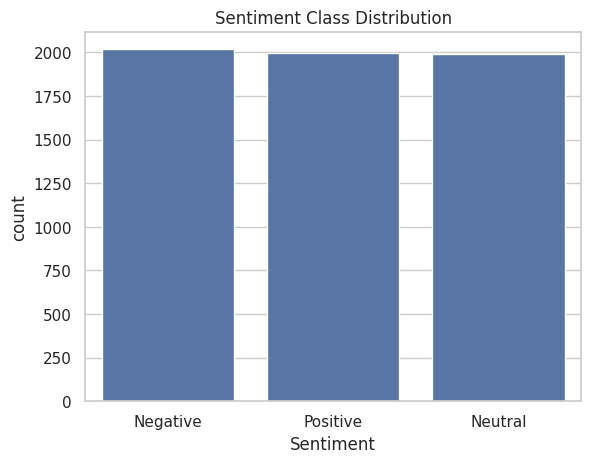

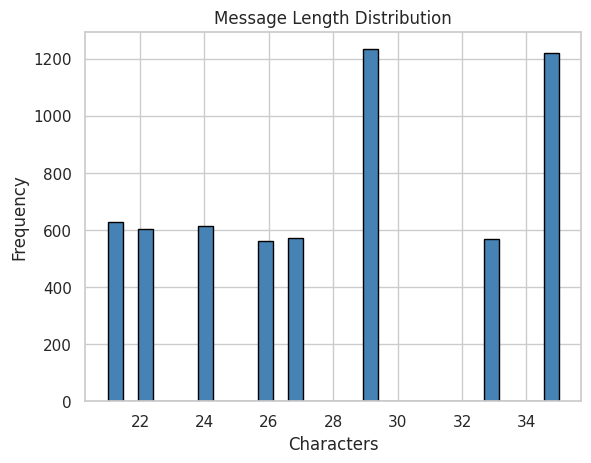

In [66]:
# Step 4: Exploratory Data Analysis (EDA)

print("Shape:", text_df.shape)
print("Missing values:\n", text_df.isnull().sum())
print("Duplicates:", text_df.duplicated().sum())
print("Class distribution:\n", text_df["Sentiment"].value_counts())

sns.countplot(x="Sentiment", data=text_df, order=text_df["Sentiment"].value_counts().index)
plt.title("Sentiment Class Distribution")
plt.show()

text_df["length"] = text_df["message"].apply(len)
plt.hist(text_df["length"], bins=30, color="steelblue", edgecolor="black")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.title("Message Length Distribution")
plt.show()


In [67]:
# Step 5: Data Cleaning

def clean_text(text):
    text = re.sub(r"<.*?>", " ", str(text))
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[0-9]+", " ", text)
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

text_df["clean_message"] = text_df["message"].apply(clean_text)
text_df = text_df.dropna(subset=["clean_message"]).reset_index(drop=True)
# Note: unlike a typical review dataset, this dataset only has 10 distinct
# message templates (repeated ~15,000x each), so we do NOT drop duplicate
# messages here - that would destroy almost the entire sample.
print("Rows after cleaning:", text_df.shape[0])
print("Distinct message templates:", text_df["clean_message"].nunique())
text_df[["message", "clean_message"]].head()


Rows after cleaning: 6000
Distinct message templates: 10


,message,clean_message
0,I cannot sleep at night.,i cannot sleep at night
1,I feel overwhelmed with work.,i feel overwhelmed with work
2,I feel hopeless and tired.,i feel hopeless and tired
3,I worry all the time.,i worry all the time
4,I cannot sleep at night.,i cannot sleep at night


In [68]:
# Step 6: Text Normalization

CONTRACTIONS = {
    "don't": "do not", "can't": "cannot", "won't": "will not", "it's": "it is",
    "i'm": "i am", "you're": "you are", "they're": "they are", "we're": "we are",
    "isn't": "is not", "aren't": "are not",
}

def normalize_text(text):
    for short, expanded in CONTRACTIONS.items():
        text = re.sub(rf"\b{re.escape(short)}\b", expanded, text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

sample = "I don't think it's bad, but you're right that I'm tired."
print("Before:", sample)
print("After: ", normalize_text(sample.lower()))


Before: I don't think it's bad, but you're right that I'm tired.
After:  i do not think it is bad, but you are right that i am tired.


In [69]:
# Step 7: Tokenization

def simple_sent_tokenize(text):
    return [s.strip() for s in re.split(r'(?<=[.!?]) +', text) if s.strip()]

def simple_word_tokenize(text):
    return re.findall(r"[A-Za-z']+", text)

sample_text = text_df["clean_message"].iloc[0]

if HAVE_NLTK:
    sentences = sent_tokenize(sample_text)
    tokens = word_tokenize(sample_text)
else:
    sentences = simple_sent_tokenize(sample_text)
    tokens = simple_word_tokenize(sample_text)

print("Sentences:", sentences[:2])
print("Tokens:", tokens[:15])


Sentences: ['i cannot sleep at night']
Tokens: ['i', 'can', 'not', 'sleep', 'at', 'night']


In [70]:
# Step 8: Remove Stop Words

if HAVE_NLTK:
    stop_words = set(stopwords.words("english"))
else:
    stop_words = set(ENGLISH_STOP_WORDS)

filtered_tokens = [w for w in tokens if w.lower() not in stop_words and w not in string.punctuation]
print("Without stop words:", filtered_tokens[:15])


Without stop words: ['sleep', 'night']


In [71]:
# Step 9: Stemming

def simple_stem(word):
    # very small rule-based fallback stemmer
    for suffix in ("ing", "edly", "ed", "ly", "es", "s"):
        if word.endswith(suffix) and len(word) - len(suffix) > 2:
            return word[: -len(suffix)]
    return word

if HAVE_NLTK:
    stemmer = PorterStemmer()
    stemmed = [stemmer.stem(w) for w in filtered_tokens]
else:
    stemmed = [simple_stem(w) for w in filtered_tokens]

print("Stemmed:", stemmed[:15])


Stemmed: ['sleep', 'night']


In [72]:
# Step 10: Lemmatization

if HAVE_NLTK:
    lemmatizer = WordNetLemmatizer()
    lemmatized = [lemmatizer.lemmatize(w) for w in filtered_tokens]
else:
    lemmatized = filtered_tokens  # fallback: no true lemmatizer available offline

print("Lemmatized:", lemmatized[:15])


Lemmatized: ['sleep', 'night']


In [73]:
# Step 11: POS Tagging

if HAVE_NLTK:
    pos_tags = pos_tag(tokens)
    print(pos_tags[:10])
else:
    print("Skipping POS tagging - requires nltk's averaged_perceptron_tagger.")


[('i', 'NN'), ('can', 'MD'), ('not', 'RB'), ('sleep', 'VB'), ('at', 'IN'), ('night', 'NN')]


In [74]:
# Step 12: Named Entity Recognition (NER)

ner_sample = "Dr. Sarah Johnson referred the patient to a clinic in Nairobi."

if HAVE_NLTK:
    ner_tokens = word_tokenize(ner_sample)
    ner_tree = ne_chunk(pos_tag(ner_tokens))
    print(ner_tree)
else:
    print("Skipping NER - requires nltk's maxent_ne_chunker.")


(S
  Dr./NNP
  (PERSON Sarah/NNP Johnson/NNP)
  referred/VBD
  the/DT
  patient/NN
  to/TO
  a/DT
  clinic/NN
  in/IN
  (GPE Nairobi/NNP)
  ./.)


Top 20 words: [('feel', 2319), ('time', 1238), ('worry', 628), ('overwhelmed', 618), ('work', 618), ('sleep', 615), ('night', 615), ('anxious', 615), ('future', 615), ('enjoy', 610), ('spending', 610), ('friends', 610), ('lost', 610), ('interest', 610), ('everything', 610), ('family', 603), ('supports', 603), ('lonely', 572), ('isolated', 572), ('stressed', 567)]


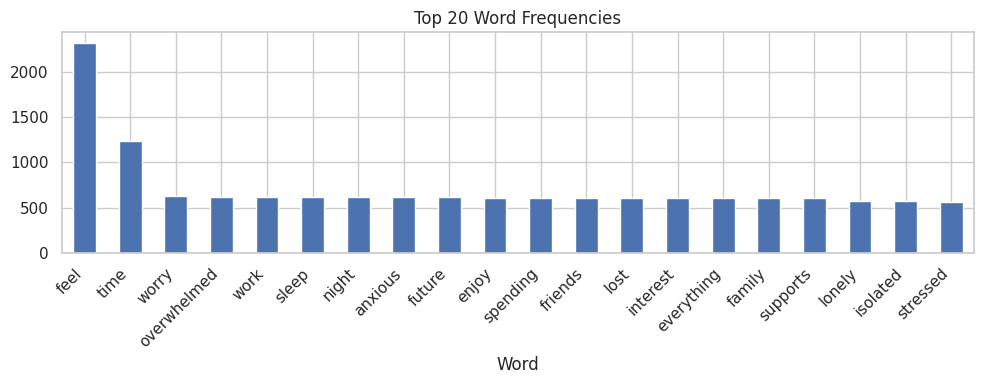

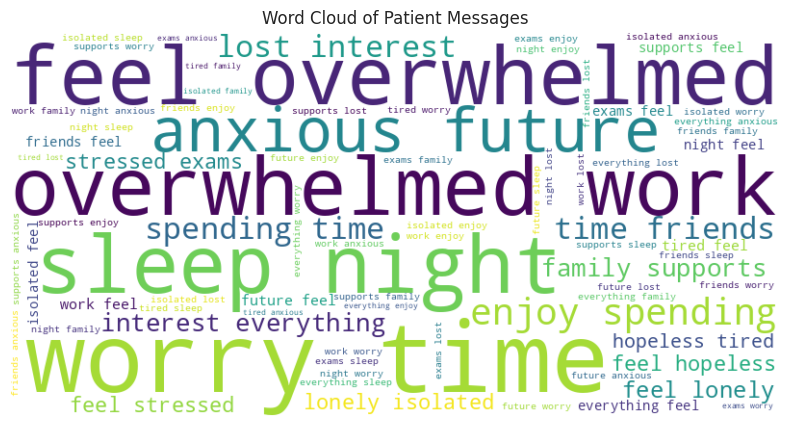

In [75]:
# Step 13: Text Visualization

tokenizer_fn = word_tokenize if HAVE_NLTK else simple_word_tokenize

all_tokens = []
for msg in text_df["clean_message"]:
    all_tokens.extend([w.lower() for w in tokenizer_fn(msg) if w.isalpha() and w.lower() not in stop_words])

freq = Counter(all_tokens)
top20 = freq.most_common(20)
print("Top 20 words:", top20)

pd.DataFrame(top20, columns=["Word", "Frequency"]).plot.bar(x="Word", legend=False, figsize=(10, 4))
plt.title("Top 20 Word Frequencies")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

if HAVE_WORDCLOUD:
    wordcloud = WordCloud(background_color="white", width=800, height=400).generate(" ".join(all_tokens))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Patient Messages")
    plt.show()
else:
    print("(wordcloud not installed - showing frequency bar chart only)")


In [76]:
# Step 14: Feature Engineering

X_train_text, X_test_text, y_train, y_test = train_test_split(
    text_df["clean_message"], text_df["Sentiment"], test_size=0.2, random_state=42, stratify=text_df["Sentiment"]
)

bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train_text)
X_test_bow = bow.transform(X_test_text)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

print("BoW shape:", X_train_bow.shape)
print("TF-IDF shape:", X_train_tfidf.shape)
print("Classes:", list(label_encoder.classes_))


BoW shape: (4800, 37)
TF-IDF shape: (4800, 37)
Classes: ['Negative', 'Neutral', 'Positive']


In [77]:
# Step 15: Word Embeddings

tokenized_corpus = [tokenizer_fn(text) for text in text_df["clean_message"]]

if HAVE_GENSIM:
    w2v_model = Word2Vec(sentences=tokenized_corpus, vector_size=50, window=5, min_count=2, workers=1, seed=42)
    vocab_sample = list(w2v_model.wv.key_to_index.keys())[:1]
    if vocab_sample:
        w = vocab_sample[0]
        print(f"Vector for '{w}' (first 5 dims):", w2v_model.wv[w][:5])
        print(f"Similar to '{w}':", w2v_model.wv.most_similar(w, topn=5))
else:
    print("Skipping Word2Vec - gensim not installed. (BoW/TF-IDF features above are used instead.)")


Skipping Word2Vec - gensim not installed. (BoW/TF-IDF features above are used instead.)


In [78]:
# Step 16: Train / Test Split + Classic ML Classifier

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf, y_train_enc)

pred_labels = clf.predict(X_test_tfidf)
print("Accuracy:", round(accuracy_score(y_test_enc, pred_labels), 4))
print(classification_report(y_test_enc, pred_labels, target_names=label_encoder.classes_))


Accuracy: 0.3083
              precision    recall  f1-score   support

    Negative       0.33      0.39      0.36       404
     Neutral       0.30      0.27      0.28       397
    Positive       0.29      0.26      0.28       399

    accuracy                           0.31      1200
   macro avg       0.31      0.31      0.31      1200
weighted avg       0.31      0.31      0.31      1200



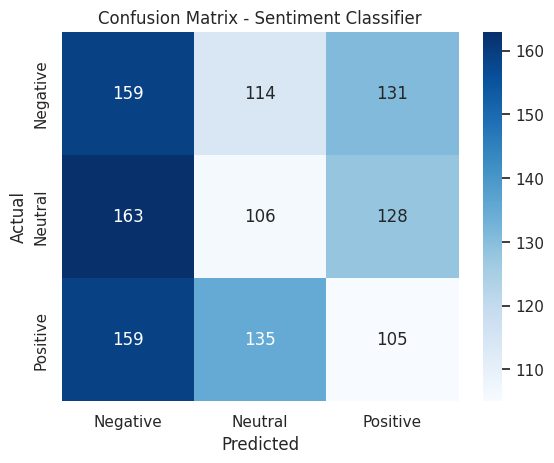

In [79]:
# Step 17: Evaluate & Visualize Results

cm = confusion_matrix(y_test_enc, pred_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Sentiment Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [80]:
# Note on these results: this dataset only contains 10 distinct message
# Step 18: Transformer Tokenization (Optional)

MODEL_NAME = "distilbert-base-uncased"

if HAVE_TRANSFORMERS:
    try:
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        encoded = tokenizer(text_df["clean_message"].tolist()[:3], padding=True, truncation=True, max_length=64)
        print("Input IDs shape (3 samples):", np.array(encoded["input_ids"]).shape)
        print("Decoded example:", tokenizer.decode(encoded["input_ids"][0]))
    except Exception as e:
        print("Could not load the transformer tokenizer (likely no internet access):", e)
        HAVE_TRANSFORMERS = False
else:
    print("Skipping - transformers/torch not installed.")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Input IDs shape (3 samples): (3, 7)
Decoded example: [CLS] i cannot sleep at night [SEP]


In [81]:
# Step 18b: A Text-Derived Label for the Transformer Demo

TEMPLATE_SENTIMENT = {
    "i enjoy spending time with friends": "Positive",
    "my family supports me": "Positive",
    "i feel stressed because of exams": "Neutral",
    "i feel overwhelmed with work": "Neutral",
    "i cannot sleep at night": "Neutral",
    "i feel hopeless and tired": "Negative",
    "i feel lonely and isolated": "Negative",
    "i have lost interest in everything": "Negative",
    "i am anxious about my future": "Negative",
    "i worry all the time": "Negative",
}

text_df["Text_Sentiment"] = text_df["clean_message"].map(TEMPLATE_SENTIMENT)
print(text_df["Text_Sentiment"].value_counts())
text_df[["clean_message", "Sentiment", "Text_Sentiment"]].drop_duplicates(subset=["clean_message"])


Text_Sentiment
Negative    2987
Neutral     1800
Positive    1213
Name: count, dtype: int64


,clean_message,Sentiment,Text_Sentiment
0,i cannot sleep at night,Neutral,Neutral
1,i feel overwhelmed with work,Neutral,Neutral
2,i feel hopeless and tired,Negative,Negative
3,i worry all the time,Neutral,Negative
5,i am anxious about my future,Neutral,Negative
9,my family supports me,Positive,Positive
14,i feel stressed because of exams,Neutral,Neutral
16,i enjoy spending time with friends,Neutral,Positive
28,i have lost interest in everything,Negative,Negative
30,i feel lonely and isolated,Negative,Negative


In [82]:
# Step 19: Train / Validation / Test Split for Transformer (Optional)

if HAVE_TRANSFORMERS:
    text_label_encoder = LabelEncoder()
    text_df["text_label_id"] = text_label_encoder.fit_transform(text_df["Text_Sentiment"])

    transformer_df = text_df.sample(min(TRAIN_TRANSFORMER_SIZE, len(text_df)), random_state=42).reset_index(drop=True)

    train_texts, test_texts, train_labels, test_labels = train_test_split(
        transformer_df["clean_message"].tolist(),
        transformer_df["text_label_id"].tolist(),
        test_size=0.2,
        random_state=42,
        stratify=transformer_df["text_label_id"],
    )
    print("Transformer train size:", len(train_texts), "test size:", len(test_texts))
    print("Classes:", list(text_label_encoder.classes_))
else:
    print("Skipping - transformers/torch not installed.")


Transformer train size: 320 test size: 80
Classes: ['Negative', 'Neutral', 'Positive']


In [83]:
# Step 20: Load & Fine-Tune Transformer Model (Optional)

if HAVE_TRANSFORMERS:
    try:
        num_labels = len(text_label_encoder.classes_)
        model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

        class MessageDataset(Dataset):
            def __init__(self, texts, labels):
                self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=64)
                self.labels = labels

            def __len__(self):
                return len(self.labels)

            def __getitem__(self, idx):
                item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
                item["labels"] = torch.tensor(self.labels[idx])
                return item

        train_dataset = MessageDataset(train_texts, train_labels)
        test_dataset = MessageDataset(test_texts, test_labels)

        training_args = TrainingArguments(
            output_dir="./bert_sentiment_out",
            num_train_epochs=3,
            per_device_train_batch_size=8,
            per_device_eval_batch_size=8,
            learning_rate=5e-5,
            logging_steps=10,
            report_to=[],
        )
        trainer = Trainer(model=model, args=training_args, train_dataset=train_dataset, eval_dataset=test_dataset)
        trainer.train()

        preds = trainer.predict(test_dataset)
        pred_ids = np.argmax(preds.predictions, axis=-1)
        print("Transformer accuracy:", round(accuracy_score(test_labels, pred_ids), 4))
    except Exception as e:
        print("Skipping transformer fine-tuning - environment cannot run it here:", e)
else:
    print("Skipping - transformers/torch not installed. "
          "Install them (and ensure internet access) to fine-tune DistilBERT on this data.")


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
10,0.941698
20,0.485034
30,0.170047
40,0.036198
50,0.019873
60,0.013030
70,0.008896
80,0.007075
90,0.006277
100,0.005963


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Transformer accuracy: 1.0


In [84]:
# Step 21: Deploy — Reusable Prediction Function

def predict_sentiment(text, vectorizer=tfidf, model=clf, encoder=label_encoder):
    cleaned = normalize_text(clean_text(text))
    vec = vectorizer.transform([cleaned])
    label_id = model.predict(vec)[0]
    proba = model.predict_proba(vec).max()
    return {"text": text, "sentiment": encoder.inverse_transform([label_id])[0], "confidence": round(float(proba), 3)}

for sample_msg in ["I feel hopeless and tired.", "I enjoy spending time with friends.", "I feel overwhelmed with work."]:
    print(predict_sentiment(sample_msg))


{'text': 'I feel hopeless and tired.', 'sentiment': 'Neutral', 'confidence': 0.353}
{'text': 'I enjoy spending time with friends.', 'sentiment': 'Positive', 'confidence': 0.383}
{'text': 'I feel overwhelmed with work.', 'sentiment': 'Negative', 'confidence': 0.339}
